# Indoor Climbing Hold Classification and Detection
This notebook covers two independent experiments on [the same Kaggle dataset](https://doi.org/10.34740/KAGGLE/DSV/13795579):

- **Classification:** a convolutional neural network that predicts hold type from cropped single-hold images
- **Detection:** a YOLOv11 model that finds and labels holds on full wall photos and video

The classification half uses sample crops and a sample pretrained CNN. Full preprocessing, training, and testing live in `process_dataset.py`, `train_model.py`, and `test_model.py`. The detection half uses checked-in plots and `sample_run/` outputs (no GPU required to view them). Retrain or run live inference with `train_yolo.py` and `predict_yolo.py`; both pick CUDA GPU 0 when available and CPU otherwise.

Both experiments use the same six hold categories:
- Crimp
- Jug
- Pinch
- Pocket
- Slope
- Volume

Classification operates on a single cropped hold per image. Detection operates on full climbing-wall frames that may contain many holds.

In [82]:
import torch
import torchvision
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

from tqdm import tqdm
from pathlib import Path
from torchvision.io import decode_image
from torch.utils.data import DataLoader, Dataset
from torch import nn
from PIL import Image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [83]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)
torch.backends.cudnn.benchmark = True

cuda:0


## Classification

## Dataset Overview
The dataset consists of three sources combined into a single training set:
- Raw images — holds photographed on clean white backgrounds
- Synthetic images — holds composited onto artificial wall backgrounds
- Real images — holds photographed on real climbing walls
Each image contains exactly one hold and one label following a YOLOv12 format.

Dataset splits
- Training set: used to learn model parameters
- Validation/Test set: used only for evaluation

The validation and test sets are never used to compute normalization statistics or sampling weights, ensuring no data leakage.

## Preprocessing
The preprocessing for the dataset occurs in `process_dataset.py`.

For each image:
- YOLO bounding boxes are used to crop individual holds
- Aspect ratio is preserved
- Images are resized to a fixed resolution (128×128)
- Padding is applied using the mean RGB color of the training set
- Images are saved to disk in their final form

This approach ensures:
- consistent input size for the network,
- minimal runtime preprocessing,
- faster and more stable training.

In [84]:
# mean RGB pixel ratio and deviation of the training set
mean = [0.6681055533042859, 0.6137803857704651, 0.5396168694315177]
std  = [0.32921997147304766, 0.3079490945893265, 0.36234998143662933]

We set up Torch transforms for the images to normalize them and to use a one-hot encoding on their respective labels, which is now an integer from 0-5.

In [85]:
classes = {
	0: 'Crimp',
	1: 'Jug',
	2: 'Pinch',
	3: 'Pocket',
	4: 'Slope',
	5: 'Volume',
}

In [86]:
transform = transforms.Compose([
	transforms.ToTensor(),
	transforms.Normalize(mean=mean, std=std),
])

target_transform = transforms.Lambda(lambda y: torch.zeros(
    6, dtype=torch.float).scatter_(dim=0, index=torch.tensor(y), value=1))

We set up the Dataset class...

In [87]:
class ClimbingHoldDataset(Dataset):
	def __init__(self, annotations_dir, img_dir, transform=None, target_transform=None):
		rows = []
		for fname in os.listdir(annotations_dir):
			annotation_path = os.path.join(annotations_dir, fname)
			class_label = np.loadtxt(annotation_path, dtype=str)
			image_fname = os.path.splitext(fname)[0] + '.jpg'
			rows.append(np.array([image_fname, class_label]))

		self.img_labels = np.array(rows, dtype=str)
		self.img_dir = img_dir
		self.transform = transform
		self.target_transform = target_transform

	def __len__(self):
		return len(self.img_labels)
	
	def __getitem__(self, idx):
		image_fname, label = self.img_labels[idx]
		img_path = os.path.join(self.img_dir, image_fname)
		image = Image.open(img_path).convert("RGB")
		label = int(label)
		if self.transform:
			image = self.transform(image)
		if self.target_transform:
			label = self.target_transform(label)
		return image, label

And create two sample datasets, one for the training split and another for the testing split (validation split left out in this notebook)

In [88]:
train_dataset_path = Path('Sample_Processed_Dataset/train')
train_dataset = ClimbingHoldDataset(
	annotations_dir=os.path.join(train_dataset_path, 'labels'),
	img_dir=os.path.join(train_dataset_path, 'images'),
	transform=transform,
	target_transform=target_transform
)

test_dataset_path = Path('Sample_Processed_Dataset/test')
test_dataset = ClimbingHoldDataset(
	annotations_dir=os.path.join(test_dataset_path, 'labels'),
	img_dir=os.path.join(test_dataset_path, 'images'),
	transform=transform,
	target_transform=target_transform
)



print(f"Training dataset size: {len(train_dataset)} samples")
print(f"Test dataset size: {len(test_dataset)} samples")

Training dataset size: 6 samples
Test dataset size: 100 samples


Then we create data loaders and iterators for the datasets.

In [89]:
train_dataloader = DataLoader(train_dataset, batch_size=6, shuffle=True,
							   pin_memory=True)
train_dataiter = iter(train_dataloader)
test_dataloader = DataLoader(test_dataset, batch_size=6, shuffle=False,
							  pin_memory=True)
test_dataiter = iter(test_dataloader)

Count the unique labels in the training dataset.

In [90]:
unique_labels, counts = np.unique(train_dataset.img_labels[:, 1], return_counts=True)
for label, count in zip(unique_labels, counts):
	class_name = classes.get(int(label), 'Unknown')
	print(f"{class_name} ({label}): {count}")

Crimp (0): 1
Jug (1): 1
Pinch (2): 1
Pocket (3): 1
Slope (4): 1
Volume (5): 1


Display the first images in the training dataset.

torch.Size([6, 3, 128, 128])
torch.Size([6, 6])


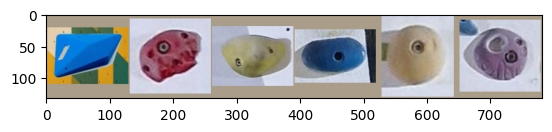

Volume	Crimp	Jug	Pinch	Slope	Pocket	

In [91]:
mean_t = torch.tensor(mean).view(3,1,1)
std_t  = torch.tensor(std).view(3,1,1)

def unnormalize(img_tensor):
    return img_tensor * std_t + mean_t

train_dataiter = iter(train_dataloader)
images, labels = next(train_dataiter)
print(images.shape)
print(labels.shape)

def imshow(img):
	img = unnormalize(img)
	npimg = img.numpy()
	plt.imshow(np.transpose(npimg, (1, 2, 0)))
	plt.show()

images_to_display = 6
imshow(torchvision.utils.make_grid(images[:images_to_display]))
for j in range(images_to_display):
	for i in range(labels.shape[1]):
		if labels[j][i].item() == 1:
			print(f"{classes[i]}\t", end='')

### Class Distribution and Imbalance
The dataset is not perfectly balanced. Some hold types (e.g. Crimps and Jugs) appear much more frequently than others (e.g. Pockets).

To address this:
- Class-weighted cross-entropy loss is used during training.
- Each class contributes to the loss inversely proportional to its frequency.
- This encourages the model to learn minority classes without artificially altering the dataset.

In [92]:
# Counts for each of the classes in the training dataset
counts = np.array([14689, 13848, 9482, 4274, 6599, 5605], dtype=np.float32)
weights = 1.0 / counts
weights = weights / weights.sum()
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

## Model Architechture
The model is a lightweight convolutional neural network consisting of:
- two convolutional layers,
- ReLU activations,
- max-pooling layers,
- and a final fully connected classification head.

The model outputs a probability distribution over the six hold classes.

In [93]:
class Net(nn.Module):
	def __init__(self):
		super().__init__()
		self.linear_relu_stack = nn.Sequential(
			nn.Conv2d(3, 16, 3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(2, 2),
			nn.Conv2d(16, 32, 3, padding=1),
			nn.ReLU(),
			nn.MaxPool2d(2, 2),
			nn.Flatten(),
			nn.Linear(32 * 32 * 32, 6),
		)

	def forward(self, x):
		x = self.linear_relu_stack(x)
		return x

In [94]:
net = Net()
net.to(device)
print(sum(p.numel() for p in net.parameters()))

201702


## Training

First we set up a loss criterion and a parameter optimizer. I chose a cross-cntropy algorithm for the loss criterion and a stochastic gradient descent algorithm for the optimizer with momentum.

In [95]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

We load a sample pretrained model to investigate:

In [96]:
checkpoint = torch.load("sample_checkpoint.pth", map_location=device)
net.load_state_dict(checkpoint["model_state"])
print(f"Currently trained for {checkpoint["epoch"]} epochs.")

Currently trained for 24 epochs.


Simple training function:

In [97]:
def train_epoch(net, dataloader, criterion, optimizer):
	net.train()
	for i, data in enumerate(dataloader, 0):
		inputs, labels = data
		inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

		optimizer.zero_grad()

		outputs = net(inputs)
		loss = criterion(outputs, torch.max(labels, 1)[1])
		loss.backward()
		optimizer.step()

Function used to evaluate model on accuracy:

In [98]:
def test_model(net, dataloader, device):
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        with tqdm(total=len(dataloader), desc="Test", unit="batch") as pbar:
            for images, labels in dataloader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = net(images)
                _, predicted = torch.max(outputs.data, 1)
                _, labels_max = torch.max(labels.data, 1)

                total += labels.size(0)
                correct += (predicted == labels_max).sum().item()
                pbar.update(1)

    accuracy = 100.0 * correct / total if total > 0 else 0.0
    print(f'Accuracy: {accuracy:.2f}%')
    return accuracy

Test the model's accuracy on the testing sample set of 50 images.

In [ ]:
# Uncomment if you have the processed dataset

# test_dataset_path = Path('Processed_Dataset/test')
# test_dataset = ClimbingHoldDataset(
# 	annotations_dir=os.path.join(test_dataset_path, 'labels'),
# 	img_dir=os.path.join(test_dataset_path, 'images'),
# 	transform=transform,
# 	target_transform=target_transform
# )
# test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False,
# 							  pin_memory=True)
# test_dataiter = iter(test_dataloader)

In [118]:
print('Baseline evaluation on testing set:')
acc = test_model(net, test_dataloader, device)

Baseline evaluation on testing set:


Test: 100%|██████████| 103/103 [00:10<00:00,  9.59batch/s]

Accuracy: 84.72%


Then, the model is trained.
A checkpoint is saved after each epoch, capturing:
- the model parameters,
- the optimizer state,
- the epoch number.

This allows:
- resuming training from any point,
- evaluating intermediate models,
- analyzing how performance evolves over time.

In total, 25 sample checkpoints (one per epoch) are available for analysis.

We begin evaluation by plotting validation accuracy as a function of training epoch.
This curve shows:
- rapid learning during early epochs,
- diminishing returns as training progresses,
- eventual plateauing of validation performance.

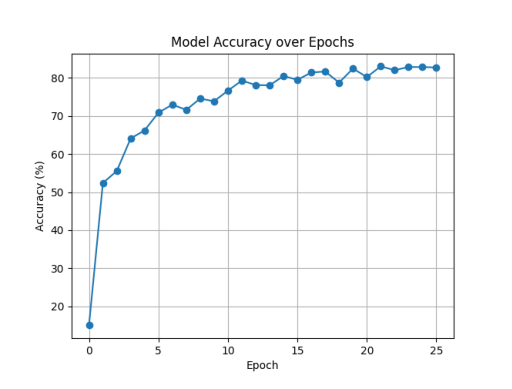

In [100]:
img = mpimg.imread('plots/sample_epochs_vs_accuracy.png')
plt.imshow(img)
plt.axis('off')
plt.show()

### Sample Prediction
We display a grid of test images with the ground truth label for the sample model to classify...

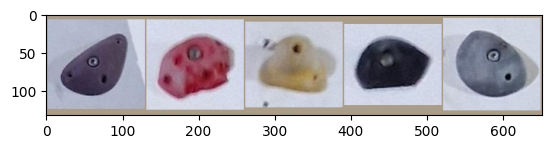

Slope	Crimp	Crimp	Crimp	Crimp	

In [131]:
images, labels = next(test_dataiter)

images_to_display = 5
imshow(torchvision.utils.make_grid(images[:images_to_display]))
for j in range(images_to_display):
	for i in range(labels.shape[1]):
		if labels[j][i].item() == 1:
			print(f"{classes[i]}\t", end='')

In [132]:
outputs = net(images.to(device))
_, predicted = torch.max(outputs, 1)
predicted = predicted.cpu()
labels = labels.cpu()
probs = torch.softmax(outputs, dim=1).cpu()
for j in range(min(images_to_display, labels.size(0))):
    actual_idx = labels.argmax(dim=1)[j].item()
    pred_idx = predicted[j].item()
    conf = probs[j, pred_idx].item()
    print(f"Actual: {classes[actual_idx]:10s}  Predicted: {classes[pred_idx]:10s}  Conf: {100*conf:.2f}%")


Actual: Slope       Predicted: Crimp       Conf: 78.14%
Actual: Crimp       Predicted: Crimp       Conf: 89.64%
Actual: Crimp       Predicted: Jug         Conf: 70.94%
Actual: Crimp       Predicted: Crimp       Conf: 80.19%
Actual: Crimp       Predicted: Crimp       Conf: 97.93%


Observing some of the predictions the model made shows that, generally, it makes mistakes on holds that are ambiguous even to humans. These errors are understandable.

### Accuracy for each Hold

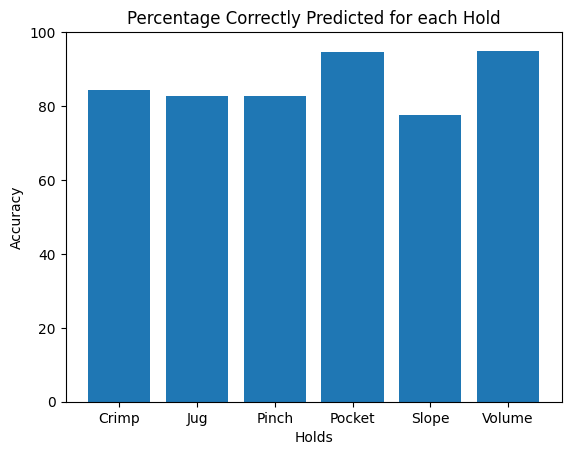

In [ ]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

list_preds = list()
list_labels = list()
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = net(images)
        _, predictions = torch.max(outputs, 1)

        predictions = predictions.cpu()
        labels = labels.cpu()

        for label, pred in zip(labels, predictions):
            label = label.argmax().item()
            list_labels.append(label)
            list_preds.append(pred.item())
            pred = pred.item()

            if pred == label:
                correct_pred[label] += 1
            total_pred[label] += 1


categories = list(classes.values())
accuracies = []
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    accuracies.append(accuracy)

plt.bar(categories, accuracies)
plt.xlabel('Holds')
plt.ylabel('Accuracy')
plt.title('Percentage Correctly Predicted for each Hold')
_, _ = plt.ylim(0, 100)

The per-class accuracy shows that the sample model, when evaluated on the full testing split, performs best when classifying either pockets or volumes and performs worst when classifying a slope.

This reveals that these two hold types are easier for the model to classify. This is understandable considering that generally, pockets are easily identifiable from a hole in the middle of the hold and volumes are more angular than the rest of the holds. Slope holds are the worst to classify, possibly because they can be easily mistaken for a crimp or a jug.

### Confusion Matrix
A confusion matrix is used here to visualize prediction patterns.

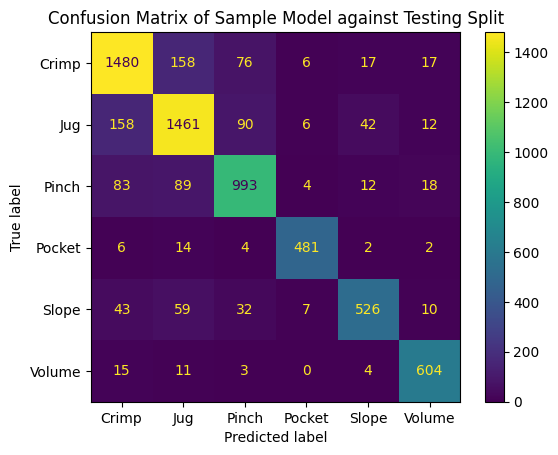

In [125]:
cm = confusion_matrix(list_labels, list_preds, labels=list(classes.keys()))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(classes.values()))
disp.plot()
plt.title("Confusion Matrix of Sample Model against Testing Split")
plt.show()

The confusion matrix shows what each class is the model mistakes for. For example, for a crimp hold, when the model incorrectly classifies it, it most likely classifies a crimp as a jug. Similarly, for slopes it is jugs, suggesting that jugs may have similar features to slopes.

## Observations and Limitations
Key observations:
- Common hold types are learned quickly
- Rare hold types benefit significantly from class-weighted loss
- Some classes remain visually ambiguous

Limitations:
- Dataset quality
- Some labels may be inherently ambiguous
- Model capacity is intentionally modest

## Conclusion
The results show that even a relatively simple CNN can learn meaningful distinctions between hold types, while highlighting areas for future improvement. The sample model, trained at 25 epochs, was able to achieve >80% accuracy on unseen images. Most classification errors were due to ambiguous holds and/or labels.

Possible extensions include:
- Deeper architechtures
- Longer training
- stronger data augmentation
- ensemble modeling

## Object detection (YOLO)
The detection experiment trains YOLOv11s on the same six classes, but on full-wall images with YOLO bounding boxes instead of cropped holds. Training used `climbing_gym.yaml` and is reproduced by `train_yolo.py`. A trained checkpoint is checked in at `runs/detect/yolov11s-climbing-gym/weights/best.pt`.

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from run_device import yolo_device

yolo_run = Path("runs/detect/yolov11s-climbing-gym")
sample_run = Path("sample_run")
device = yolo_device()
print("YOLO device:", device)

Training (commented) matches `train_yolo.py`: 100 epochs, image size 640, early stopping with patience 5. Uncomment to retrain, or run `python train_yolo.py`.

In [ ]:
# Prefer: python train_yolo.py
# results = model.train(
#     data="climbing_gym.yaml",
#     epochs=100,
#     imgsz=640,
#     batch=-1,
#     multi_scale=True,
#     amp=device != "cpu",
#     cache=True,
#     patience=5,
#     name="yolov11s-climbing-gym",
#     device=device,
# )

Checked-in plots from the trained run (`results.png` and the confusion matrix) instead of re-running 100 epochs:

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, title in zip(
    axes,
    ["results.png", "confusion_matrix_normalized.png"],
    ["YOLO training results", "YOLO confusion matrix (normalized)"],
):
    ax.imshow(mpimg.imread(yolo_run / name))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Sample inference
`sample_run/` holds annotated outputs from a previous predict pass (`predict2` in the detection repo): a still (`sample_image.jpg`) and a video (`magnus_sample.avi`). Source files for live inference are in `samples/`.

In [ ]:
sample_run = Path("sample_run")
img = mpimg.imread(sample_run / "sample_image.jpg")
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Sample YOLO detections")
plt.show()

Optional live prediction on `samples/` (writes a new run under `runs/detect/`, which is gitignored). Uses the same auto device as `predict_yolo.py`. For video, use `samples/videos/magnus_sample.mp4` or `python predict_yolo.py samples/videos/magnus_sample.mp4`. The annotated sample video is `sample_run/magnus_sample.avi`.

In [ ]:
# from ultralytics import YOLO
#
# model = YOLO(yolo_run / "weights" / "best.pt")
# results = model.predict(
#     source=Path("samples/images") / "sample_image.webp",
#     device=device,
#     save=True,
#     show_labels=False,
# )
#
# results = model.predict(
#     source=Path("samples/videos") / "magnus_sample.mp4",
#     device=device,
#     save=True,
#     vid_stride=1,
#     augment=True,
#     show_labels=True,
#     show_conf=False,
#     conf=0.35,
#     stream=False,
# )